# 3.3 Annotation Ceiling

Estimate inter-annotation agreement for UdonPred evaluation datasets that overlap at protein or residue level. This is an annotation agreement estimate, not model performance.


## Method

This notebook estimates an experimental annotation ceiling by comparing labels from different UdonPred evaluation datasets on proteins that appear in both datasets. High agreement suggests that a model could, in principle, transfer between those disorder definitions. Low agreement suggests that the datasets encode different disorder concepts, contain annotation noise, or have limited overlap.

This is not model performance. It is an inter-annotation agreement estimate and should be interpreted as an approximate upper-bound diagnostic for cross-dataset transfer.


In [1]:
import subprocess
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"

ceiling_dir = RESULTS / "annotation_ceiling"
summary_csv = ceiling_dir / "annotation_ceiling_summary.csv"
overlap_csv = ceiling_dir / "overlap_details.csv"

if summary_csv.exists() and overlap_csv.exists():
    print("Annotation ceiling results already exist, skipping computation.")
else:
    print("Running annotation ceiling computation...")
    ceiling_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        str(ROOT / "scripts" / "estimate_annotation_ceiling.py"),
        "--udonpred-dir",
        str(ROOT / "UdonPred"),
        "--output-dir",
        str(ceiling_dir),
    ]
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    result.check_returncode()

ceiling_summary = pd.read_csv(summary_csv)
overlap_details = pd.read_csv(overlap_csv)

ceiling_summary["pair"] = ceiling_summary["dataset_a"] + " vs " + ceiling_summary["dataset_b"]
overlap_details["pair"] = overlap_details["dataset_a"] + " vs " + overlap_details["dataset_b"]

ceiling_summary.head()


Annotation ceiling results already exist, skipping computation.


,dataset_a,dataset_b,match_mode,n_proteins_overlap,n_residues_compared,annotation_type_a,annotation_type_b,metric,value,threshold_used,notes,pair
0,trizod,chezod,sequence,1,138,continuous,continuous,spearman,0.481978,0.5,CheZOD labels negated following existing proje...,trizod vs chezod
1,trizod,chezod,sequence,1,138,continuous,continuous,pearson,0.518136,0.5,CheZOD labels negated following existing proje...,trizod vs chezod
2,trizod,chezod,sequence,1,138,continuous,continuous,mae,1.759833,0.5,CheZOD labels negated following existing proje...,trizod vs chezod
3,trizod,chezod,sequence,1,138,continuous,continuous,rmse,2.086588,0.5,CheZOD labels negated following existing proje...,trizod vs chezod
4,trizod,softdis,sequence,6,563,continuous,continuous,spearman,0.481151,0.5,NaN,trizod vs softdis


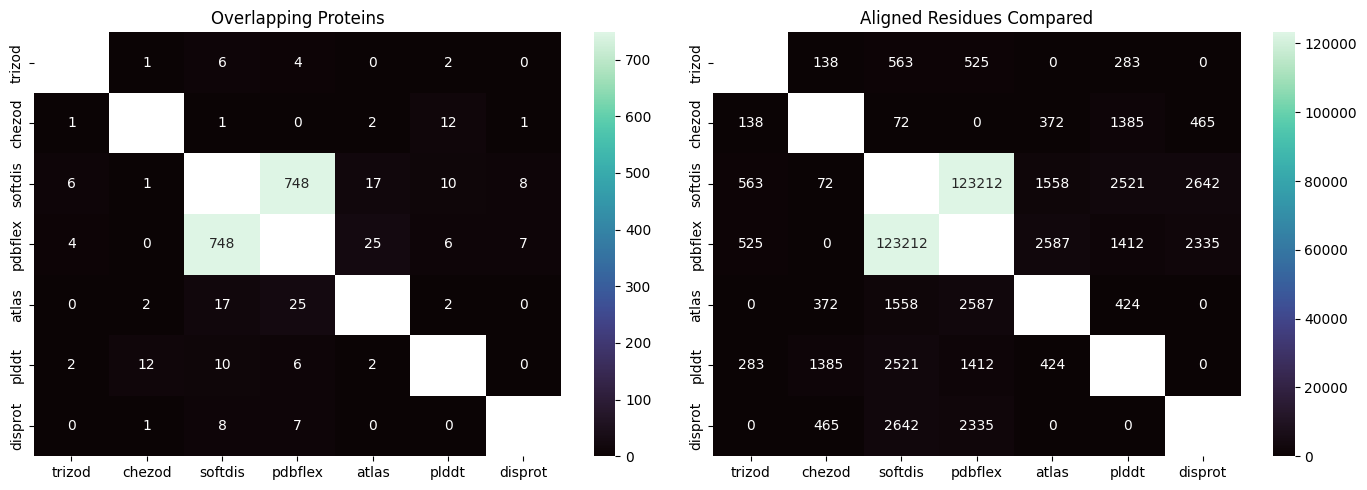

,dataset_a,dataset_b,match_mode,n_proteins_overlap,n_residues_compared
35,softdis,pdbflex,sequence,748,123212
47,softdis,disprot,sequence,8,2642
51,pdbflex,atlas,sequence,25,2587
43,softdis,plddt,sequence,10,2521
59,pdbflex,disprot,sequence,7,2335
39,softdis,atlas,id+sequence,17,1558
55,pdbflex,plddt,sequence,6,1412
27,chezod,plddt,sequence,12,1385
4,trizod,softdis,sequence,6,563
8,trizod,pdbflex,sequence,4,525


In [2]:
dataset_order = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]

all_pairs = ceiling_summary.drop_duplicates(["dataset_a", "dataset_b"])[
    ["dataset_a", "dataset_b", "match_mode", "n_proteins_overlap", "n_residues_compared"]
]

residue_overlap = pd.DataFrame(np.nan, index=dataset_order, columns=dataset_order)
protein_overlap = pd.DataFrame(np.nan, index=dataset_order, columns=dataset_order)
match_modes = pd.DataFrame("", index=dataset_order, columns=dataset_order)

for row in all_pairs.itertuples(index=False):
    residue_overlap.loc[row.dataset_a, row.dataset_b] = row.n_residues_compared
    residue_overlap.loc[row.dataset_b, row.dataset_a] = row.n_residues_compared
    protein_overlap.loc[row.dataset_a, row.dataset_b] = row.n_proteins_overlap
    protein_overlap.loc[row.dataset_b, row.dataset_a] = row.n_proteins_overlap
    match_modes.loc[row.dataset_a, row.dataset_b] = row.match_mode
    match_modes.loc[row.dataset_b, row.dataset_a] = row.match_mode

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    protein_overlap,
    annot=True,
    fmt=".0f",
    cmap="mako",
    mask=protein_overlap.isna(),
    ax=axes[0],
)
axes[0].set_title("Overlapping Proteins")
sns.heatmap(
    residue_overlap,
    annot=True,
    fmt=".0f",
    cmap="mako",
    mask=residue_overlap.isna(),
    ax=axes[1],
)
axes[1].set_title("Aligned Residues Compared")
plt.tight_layout()
plt.show()

all_pairs.sort_values("n_residues_compared", ascending=False).head(10)


## Overlap Caution

Agreement estimates are only meaningful when enough residues overlap. Pairs with very few overlapping residues should be interpreted cautiously, even if their agreement metric is high.


In [3]:
small_overlap_pairs = all_pairs.sort_values("n_residues_compared").head(10)
small_overlap_pairs


,dataset_a,dataset_b,match_mode,n_proteins_overlap,n_residues_compared
68,plddt,disprot,none,0,0
67,atlas,disprot,none,0,0
22,chezod,pdbflex,none,0,0
12,trizod,atlas,none,0,0
17,trizod,disprot,none,0,0
18,chezod,softdis,sequence,1,72
0,trizod,chezod,sequence,1,138
13,trizod,plddt,sequence,2,283
23,chezod,atlas,sequence,2,372
63,atlas,plddt,sequence,2,424


## Primary Agreement Metric

For continuous-continuous dataset pairs, the primary agreement metric is Spearman correlation. For pairs involving DisProt, which is binary, the primary agreement metric is AUROC. These choices mirror the evaluation style used in the UdonPred 7x7 matrix: continuous test datasets use rank correlation, while DisProt uses binary ranking metrics.


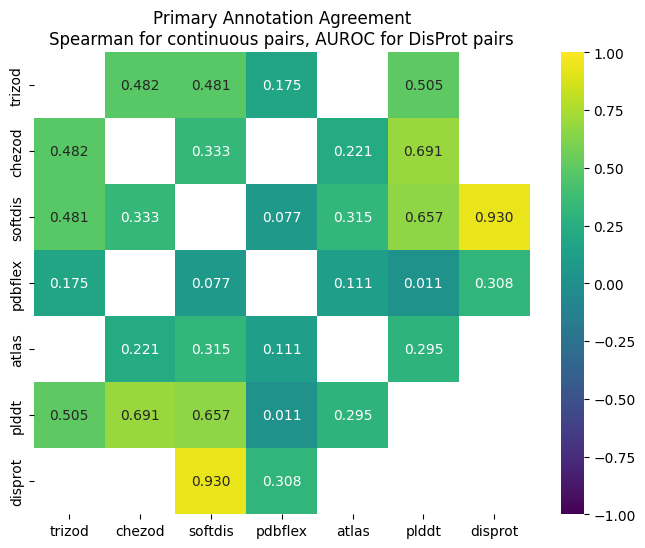

,dataset_a,dataset_b,metric,value,n_residues_compared,match_mode
11,softdis,pdbflex,spearman,0.077090,123212,sequence
14,softdis,disprot,auroc,0.929907,2642,sequence
15,pdbflex,atlas,spearman,0.111006,2587,sequence
13,softdis,plddt,spearman,0.656777,2521,sequence
17,pdbflex,disprot,auroc,0.307951,2335,sequence
12,softdis,atlas,spearman,0.315038,1558,id+sequence
16,pdbflex,plddt,spearman,0.011500,1412,sequence
9,chezod,plddt,spearman,0.691031,1385,sequence
1,trizod,softdis,spearman,0.481151,563,sequence
2,trizod,pdbflex,spearman,0.174514,525,sequence


In [4]:
primary_metrics = {
    "continuous-continuous": "spearman",
    "continuous-binary": "auroc",
    "binary-continuous": "auroc",
    "binary-binary": "mcc",
}

primary_rows = []
for row in all_pairs.itertuples(index=False):
    pair_metrics = ceiling_summary[
        (ceiling_summary["dataset_a"] == row.dataset_a)
        & (ceiling_summary["dataset_b"] == row.dataset_b)
    ].copy()
    if pair_metrics.empty:
        continue
    type_key = f"{pair_metrics.iloc[0]['annotation_type_a']}-{pair_metrics.iloc[0]['annotation_type_b']}"
    metric = primary_metrics.get(type_key, "spearman")
    metric_row = pair_metrics[pair_metrics["metric"] == metric]
    if metric_row.empty:
        value = np.nan
    else:
        value = metric_row.iloc[0]["value"]
    primary_rows.append(
        {
            "dataset_a": row.dataset_a,
            "dataset_b": row.dataset_b,
            "metric": metric,
            "value": value,
            "n_residues_compared": row.n_residues_compared,
            "match_mode": row.match_mode,
        }
    )

primary_agreement = pd.DataFrame(primary_rows)
agreement_matrix = pd.DataFrame(np.nan, index=dataset_order, columns=dataset_order)
for row in primary_agreement.itertuples(index=False):
    agreement_matrix.loc[row.dataset_a, row.dataset_b] = row.value
    agreement_matrix.loc[row.dataset_b, row.dataset_a] = row.value

plt.figure(figsize=(8, 6))
sns.heatmap(
    agreement_matrix,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    mask=agreement_matrix.isna(),
)
plt.title("Primary Annotation Agreement\nSpearman for continuous pairs, AUROC for DisProt pairs")
plt.show()

primary_agreement.sort_values("n_residues_compared", ascending=False)


## Compare UdonPred To The Estimated Ceiling

The table below compares UdonPred transfer scores with the primary annotation agreement for the same dataset pair where the metric is comparable. This is a rough diagnostic, not a strict mathematical bound, because the ceiling is estimated only on overlapping proteins/residues while the UdonPred matrix is evaluated on full test sets.

For pairs involving DisProt, only directions where DisProt is the test dataset are directly comparable to the AUROC ceiling metric.


In [5]:
udon_matrix_path = RESULTS / "udonpred_matrix" / "matrix.csv"
if not udon_matrix_path.exists():
    raise FileNotFoundError(
        f"Missing {udon_matrix_path}. Run the UdonPred matrix notebook/script first."
    )

udon_matrix = pd.read_csv(udon_matrix_path).set_index("train_dataset")

def udon_column_for_test_dataset(test_dataset):
    if test_dataset == "disprot":
        return "disprot\n(AUROC)"
    return test_dataset

def udon_metric_for_test_dataset(test_dataset):
    if test_dataset == "disprot":
        return "auroc"
    return "spearman"

comparison_rows = []
for row in primary_agreement.itertuples(index=False):
    for train_dataset, test_dataset in [
        (row.dataset_a, row.dataset_b),
        (row.dataset_b, row.dataset_a),
    ]:
        test_metric = udon_metric_for_test_dataset(test_dataset)
        if test_metric != row.metric:
            continue
        column = udon_column_for_test_dataset(test_dataset)
        udon_value = udon_matrix.loc[train_dataset, column]
        comparison_rows.append(
            {
                "train_dataset": train_dataset,
                "test_dataset": test_dataset,
                "ceiling_pair": f"{row.dataset_a} vs {row.dataset_b}",
                "metric": row.metric,
                "udon_score": udon_value,
                "annotation_ceiling": row.value,
                "gap_to_ceiling": row.value - udon_value,
                "n_residues_compared": row.n_residues_compared,
                "match_mode": row.match_mode,
            }
        )

udon_vs_ceiling = pd.DataFrame(comparison_rows).sort_values(
    ["metric", "gap_to_ceiling"], ascending=[True, True]
)
udon_vs_ceiling


,train_dataset,test_dataset,ceiling_pair,metric,udon_score,annotation_ceiling,gap_to_ceiling,n_residues_compared,match_mode
31,pdbflex,disprot,pdbflex vs disprot,auroc,0.737309,0.307951,-0.429358,2335,sequence
26,softdis,disprot,softdis vs disprot,auroc,0.917547,0.929907,0.012360,2642,sequence
10,trizod,disprot,trizod vs disprot,auroc,0.929508,NaN,NaN,0,none
19,chezod,disprot,chezod vs disprot,auroc,0.925150,NaN,NaN,465,sequence
34,atlas,disprot,atlas vs disprot,auroc,0.920100,NaN,NaN,0,none
35,plddt,disprot,plddt vs disprot,auroc,0.927180,NaN,NaN,0,none
29,pdbflex,plddt,pdbflex vs plddt,spearman,0.519823,0.011500,-0.508323,1412,sequence
32,atlas,plddt,atlas vs plddt,spearman,0.718784,0.295052,-0.423732,424,sequence
16,atlas,chezod,chezod vs atlas,spearman,0.594801,0.220828,-0.373973,372,sequence
22,softdis,atlas,softdis vs atlas,spearman,0.596582,0.315038,-0.281544,1558,id+sequence


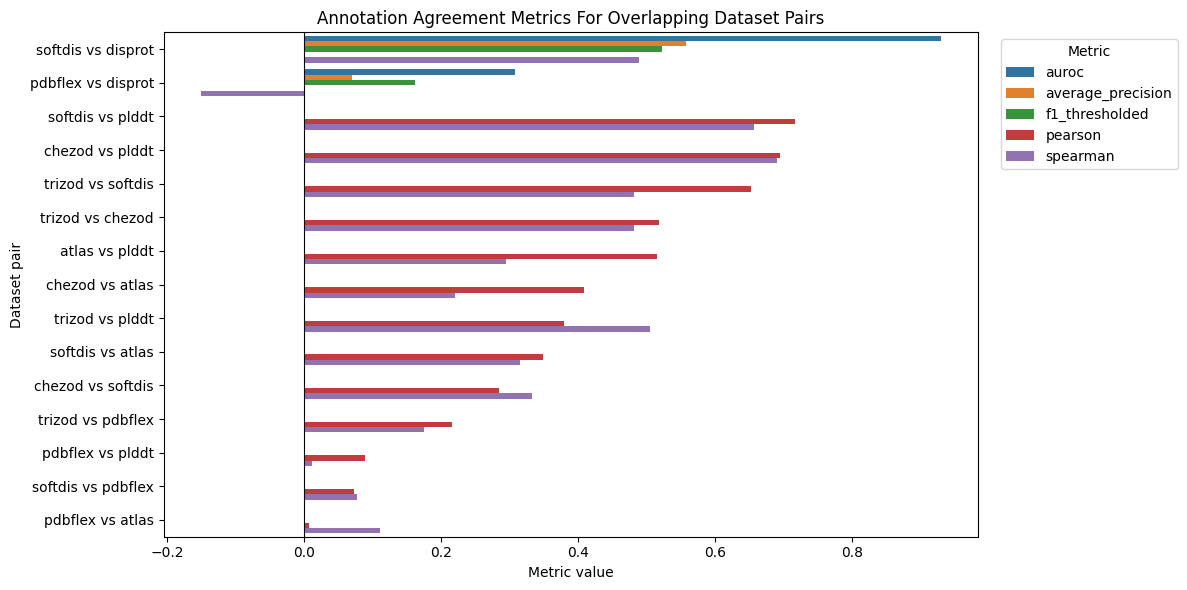

In [6]:
metric_plot = ceiling_summary[
    ceiling_summary["metric"].isin(["spearman", "pearson", "auroc", "average_precision", "f1_thresholded"])
    & ceiling_summary["value"].notna()
].copy()
metric_plot["comparison"] = metric_plot["dataset_a"] + " vs " + metric_plot["dataset_b"]
metric_plot = metric_plot.sort_values(["metric", "value"], ascending=[True, False])

plt.figure(figsize=(12, 6))
sns.barplot(data=metric_plot, x="value", y="comparison", hue="metric")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Metric value")
plt.ylabel("Dataset pair")
plt.title("Annotation Agreement Metrics For Overlapping Dataset Pairs")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [7]:
ceiling_summary[
    ceiling_summary["notes"].notna() & (ceiling_summary["notes"] != "")
][["dataset_a", "dataset_b", "metric", "value", "notes"]].drop_duplicates().head(20)


,dataset_a,dataset_b,metric,value,notes
0,trizod,chezod,spearman,0.481978,CheZOD labels negated following existing proje...
1,trizod,chezod,pearson,0.518136,CheZOD labels negated following existing proje...
2,trizod,chezod,mae,1.759833,CheZOD labels negated following existing proje...
3,trizod,chezod,rmse,2.086588,CheZOD labels negated following existing proje...
12,trizod,atlas,no_overlap,NaN,no exact ID or exact sequence overlap with eno...
13,trizod,plddt,spearman,0.504646,pLDDT converted to disorder score as 1 - pLDDT...
14,trizod,plddt,pearson,0.379056,pLDDT converted to disorder score as 1 - pLDDT...
15,trizod,plddt,mae,0.319844,pLDDT converted to disorder score as 1 - pLDDT...
16,trizod,plddt,rmse,0.446339,pLDDT converted to disorder score as 1 - pLDDT...
17,trizod,disprot,no_overlap,NaN,no exact ID or exact sequence overlap with eno...


## Interpretation Notes

After running the notebook, summarize the result in terms of dataset agreement rather than model accuracy:

- Strongest annotation agreement: fill in from `primary_agreement.sort_values("value", ascending=False)`.
- Weakest annotation agreement: fill in from `primary_agreement.sort_values("value")`.
- Pairs with low agreement should not be expected to transfer well, even for a strong model.
- Pairs with small overlap should be treated as low-confidence ceiling estimates.
- Negative `gap_to_ceiling` values in the comparison table mean UdonPred exceeds this approximate overlap-based ceiling estimate; this usually indicates that the estimate is noisy, based on limited overlap, or not directly comparable to the full-test-set UdonPred score.
